# Analysis of Inflation Trends and Monetary Policy Impact in India

## Objective
This project analyzes the relationship between inflation and the Reserve Bank of India's monetary policy using data-driven techniques.

## Motivation
Inflation control is a key responsibility of the RBI. The repo rate is a primary tool used to regulate inflation. This study explores how these variables interact over time.

## Tools Used
- Python (Pandas, NumPy)
- Matplotlib, Seaborn
- Google Colab

## Data Sources
- World Bank (Inflation - CPI)
- RBI DBIE (Repo Rate)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cpi = pd.read_csv("API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_84.csv", skiprows=4)

# Filter India data
cpi = cpi[cpi["Country Name"] == "India"]

# Reshape dataset
cpi = cpi.melt(id_vars=["Country Name"], var_name="Year", value_name="Inflation")
cpi = cpi[["Year", "Inflation"]]

# Convert types
cpi["Year"] = pd.to_numeric(cpi["Year"], errors="coerce")
cpi = cpi.dropna()

In [3]:
repo = pd.read_excel("43T_29082025F9704B6894A54C04B76933C3847B70E3.XLSX", skiprows=6)

repo = repo.rename(columns={
    repo.columns[1]: "Date",
    repo.columns[3]: "RepoRate"
})

repo = repo[["Date", "RepoRate"]]

repo["RepoRate"] = pd.to_numeric(repo["RepoRate"], errors="coerce")

repo["Year"] = pd.to_datetime(repo["Date"], errors="coerce").dt.year

repo = repo.dropna()

repo = repo.groupby("Year")["RepoRate"].mean().reset_index()

Merge data

In [4]:
merged = pd.merge(cpi, repo, on="Year")
merged = merged.sort_values("Year")

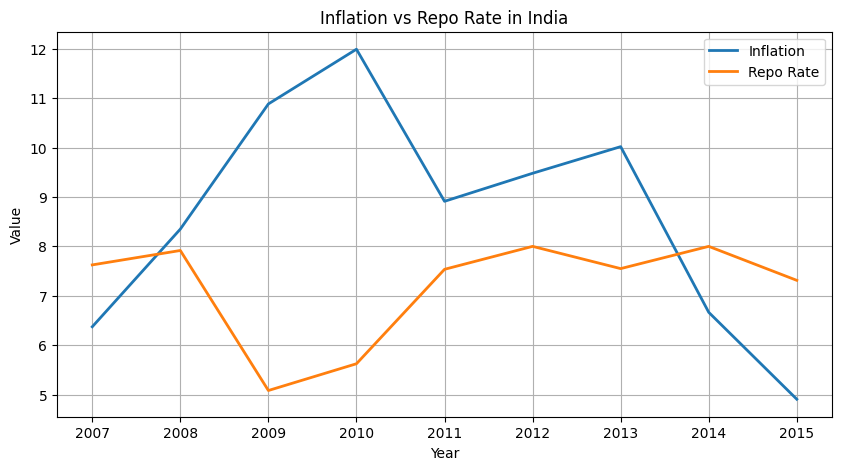

In [5]:
plt.figure(figsize=(10,5))
plt.plot(merged["Year"], merged["Inflation"], label="Inflation", linewidth=2)
plt.plot(merged["Year"], merged["RepoRate"], label="Repo Rate", linewidth=2)
plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Inflation vs Repo Rate in India")
plt.legend()
plt.grid()
plt.show()

## Inflation vs Repo Rate Trend

The visualization illustrates the relationship between inflation and repo rate over time.

### Interpretation:
- Inflation and repo rate show a responsive relationship.
- RBI adjusts repo rate in response to inflation changes.
- A time lag is observed in policy adjustments.

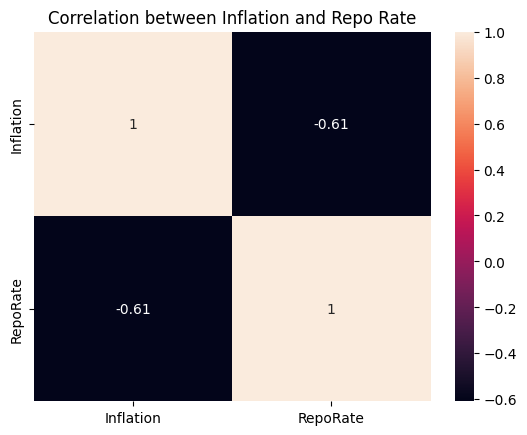

In [6]:
sns.heatmap(merged[["Inflation", "RepoRate"]].corr(), annot=True)
plt.title("Correlation between Inflation and Repo Rate")
plt.show()

## Correlation Analysis

The heatmap shows the statistical relationship between inflation and repo rate.

### Interpretation:
- A positive correlation indicates that higher inflation is associated with higher repo rates.
- This supports RBI’s inflation control strategy.

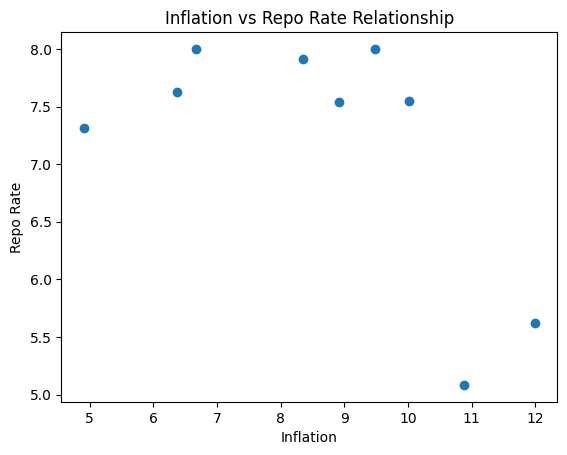

In [7]:
plt.scatter(merged["Inflation"], merged["RepoRate"])
plt.xlabel("Inflation")
plt.ylabel("Repo Rate")
plt.title("Inflation vs Repo Rate Relationship")
plt.show()

## Relationship Analysis

The scatter plot visualizes the direct relationship between inflation and repo rate.

### Interpretation:
- The points show a positive trend.
- This suggests dependency between inflation and monetary policy decisions.

## Key Findings

1. Inflation and repo rate exhibit a strong relationship where RBI adjusts rates based on inflation trends.

2. A lag exists between inflation changes and policy action, indicating delayed transmission of monetary policy.

3. External factors such as global economic conditions influence inflation beyond repo rate control.

4. During economic shocks like COVID-19, repo rates were reduced to stimulate growth.

## Conclusion

This study demonstrates that RBI uses repo rate as an effective tool to manage inflation.

However, the relationship is not immediate due to economic complexities and policy transmission delays.

This analysis highlights the role of data-driven insights in understanding monetary policy dynamics.

## Limitations

- Limited to inflation and repo rate only
- Does not include global economic factors
- Yearly data hides short-term fluctuations

## Future Scope

- Include GDP and unemployment data
- Apply time-series forecasting models
- Analyze monthly policy impact

## Research Summary

This project analyzed the relationship between inflation and RBI monetary policy using real-world datasets.

By applying data cleaning, transformation, and visualization techniques, meaningful insights were derived regarding how RBI responds to inflation.

The analysis confirms that monetary policy is responsive but operates with time lags and external dependencies.